# Visualizing the Loss Landscape of Neural Nets

In this lab we reproduce (in simplified form) key results from the paper:

> Li, Xu, Taylor, Studer, Goldstein. *Visualizing the Loss Landscape of Neural Nets.* NeurIPS 2018.

We will train small ResNet-style models on FashionMNIST with and without skip connections, then implement the paper's visualization methods to see how architecture choices shape the loss landscape.

### Recommended Reading
1. [Visualizing the Loss Landscape of Neural Nets (arXiv)](https://arxiv.org/abs/1712.09913)
2. [loss-landscape GitHub repository](https://github.com/tomgoldstein/loss-landscape) — authors' original code
3. [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — the original ResNet paper

## 1. Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.auto import tqdm

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## 2. Data

We use [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist) — 28x28 grayscale images of clothing items (10 classes). It is harder than MNIST but trains much faster than CIFAR-10 due to the single channel and smaller spatial size.

We train on a **10K subset** to keep training fast on CPU (~30s per model). For loss landscape evaluation we use a separate **1K subset** of the test set.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

def get_subset_loader(dataset, num_samples: int, batch_size: int = 256, shuffle: bool = False) -> torch.utils.data.DataLoader:
    """Create a DataLoader from a random subset of the dataset."""
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    subset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2)

TRAIN_SUBSET = 10_000

trainloader = get_subset_loader(trainset, num_samples=TRAIN_SUBSET, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=2)
eval_loader = get_subset_loader(testset, num_samples=1000, batch_size=512)

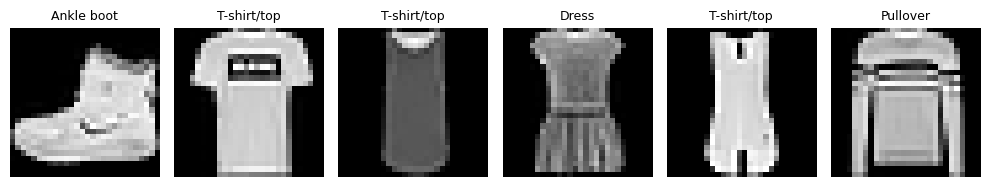

In [4]:
classes = trainset.classes

fig, axes = plt.subplots(1, 6, figsize=(10, 2))

for i, ax in enumerate(axes):
    image, label = trainset[i]

    image = image * 0.3530 + 0.2860

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Model Architectures

We define a simple ResNet-style architecture with a `use_skip` flag. When `use_skip=True`, the model uses residual connections. When `use_skip=False`, it becomes a plain convolutional network (equivalent to *ResNet-noshort* in the paper).

The architecture has 3 groups of layers with channels `[16, 32, 64]`. The `num_blocks` parameter controls how many basic blocks are in each group: this lets us vary the network depth.

**Depth formula:** total layers = 1 (initial conv) + 2 × sum(num_blocks) + 1 (fc)  
For example: `[3, 3, 3]` → 1 + 18 + 1 = **20 layers**

In [5]:
class BasicBlock(nn.Module):
    """A basic residual block: two 3x3 convolutions with optional skip connection."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, use_skip: bool = True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out += self.shortcut(x)
        out = self.relu(out)
        return out


class SimpleResNet(nn.Module):
    """
    A simplified ResNet for FashionMNIST.

    Architecture: conv -> [group1 x N] -> [group2 x N] -> [group3 x N] -> avgpool -> fc
    Channels:      16       16               32               64
    """

    def __init__(self, num_blocks: list[int] = [3, 3, 3], num_classes: int = 10, use_skip: bool = True):
        super().__init__()
        self.in_channels = 16
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(1, 16, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(64, num_blocks[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels: int, num_blocks: int, stride: int) -> nn.Sequential:
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s, self.use_skip))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model_skip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=True)
model_noskip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=False)

print(f"With skip connections:    {count_parameters(model_skip):,} parameters")
print(f"Without skip connections: {count_parameters(model_noskip):,} parameters")

With skip connections:    272,186 parameters
Without skip connections: 269,434 parameters


## 4. Training

We train both models using SGD with momentum for **10 epochs**.

In [6]:
def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    epochs: int = 10,
    lr: float = 0.1,
    device: torch.device = device,
) -> tuple[list[float], list[float]]:
    """Train a model and return (train_losses, test_accuracies) per epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.to(device)
    train_losses = []
    test_accs = []

    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss = 0.0
        for inputs, targets in trainloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        train_losses.append(running_loss / len(trainloader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in testloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        acc = 100.0 * correct / total
        test_accs.append(acc)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.2f}%")

    return train_losses, test_accs

In [7]:
print("=== Training model WITH skip connections ===")
losses_skip, accs_skip = train_model(model_skip, trainloader, testloader)

print("\n=== Training model WITHOUT skip connections ===")
losses_noskip, accs_noskip = train_model(model_noskip, trainloader, testloader)

=== Training model WITH skip connections ===


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10 — Loss: 1.1005, Test Acc: 28.53%
  Epoch 2/10 — Loss: 0.7018, Test Acc: 61.28%
  Epoch 3/10 — Loss: 0.5598, Test Acc: 31.83%
  Epoch 4/10 — Loss: 0.4834, Test Acc: 74.17%
  Epoch 5/10 — Loss: 0.4282, Test Acc: 69.54%
  Epoch 6/10 — Loss: 0.3742, Test Acc: 77.72%
  Epoch 7/10 — Loss: 0.3501, Test Acc: 85.05%
  Epoch 8/10 — Loss: 0.2972, Test Acc: 85.61%
  Epoch 9/10 — Loss: 0.2710, Test Acc: 88.06%
  Epoch 10/10 — Loss: 0.2496, Test Acc: 88.41%

=== Training model WITHOUT skip connections ===


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10 — Loss: 1.3402, Test Acc: 42.72%
  Epoch 2/10 — Loss: 0.8761, Test Acc: 40.96%
  Epoch 3/10 — Loss: 0.7386, Test Acc: 70.15%
  Epoch 4/10 — Loss: 0.5663, Test Acc: 65.16%
  Epoch 5/10 — Loss: 0.4867, Test Acc: 73.28%
  Epoch 6/10 — Loss: 0.4699, Test Acc: 74.70%
  Epoch 7/10 — Loss: 0.4230, Test Acc: 76.04%
  Epoch 8/10 — Loss: 0.3905, Test Acc: 84.62%
  Epoch 9/10 — Loss: 0.3616, Test Acc: 85.01%
  Epoch 10/10 — Loss: 0.3392, Test Acc: 85.64%


In [ ]:
# Sieć konwolucyjna z połączeniami rezydualnymi radzi sobie lepiej - różnica kilku punktów procentowych nie wydaje się dużą, ale w rzeczywistości przebijanie "sufitu" staje się coraz cięższe.
# Różnica między 88.41%, a 85.64% to redukcja błędu o około 19% (z 14.35% do 11.59%).

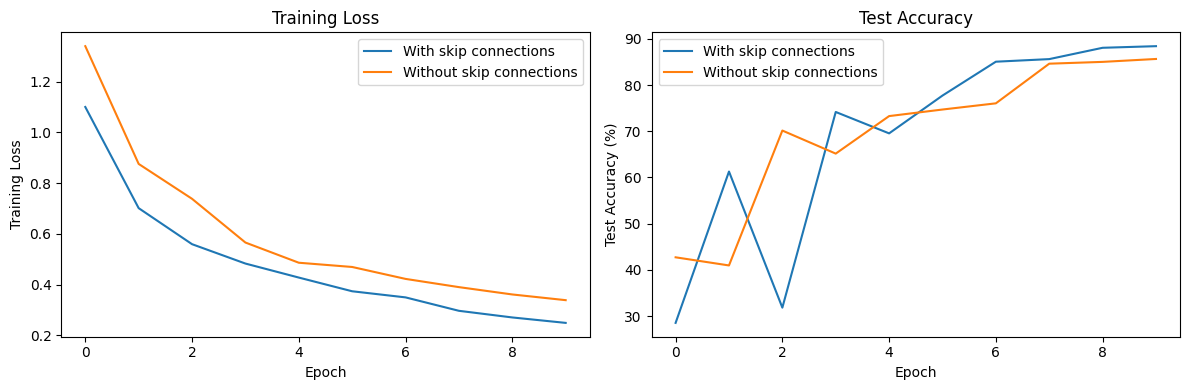

Final test accuracy — with skip: 88.41%, without skip: 85.64%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_skip, label="With skip connections")
ax1.plot(losses_noskip, label="Without skip connections")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.legend()

ax2.plot(accs_skip, label="With skip connections")
ax2.plot(accs_noskip, label="Without skip connections")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Test Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final test accuracy — with skip: {accs_skip[-1]:.2f}%, without skip: {accs_noskip[-1]:.2f}%")

## 5. Loss Evaluation Utility

A helper function that computes the average cross-entropy loss of a model on a given dataloader.

In [9]:
@torch.no_grad()
def evaluate_loss(model: nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device = device) -> float:
    """Compute average cross-entropy loss on the given dataloader."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    model.to(device)
    total_loss = 0.0
    total_samples = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * targets.size(0)
        total_samples += targets.size(0)
    return total_loss / total_samples

In [ ]:
# Podczas treningu model uczy się dopasowująć swoje wagi theta tak, żeby najlepiej klasyfikować obrazki. Ocenę, jak dobrze to robi, mierzy funkcja straty L (cross-entropy).
# Podczas treningu szukamy takich wag theta*, dla których funkcja L jest jak najmniejsza.

# Po treningu chcemy zwizualizować, jak wygląda otoczenie doliny, do której podczas treningu zbiegliśmy - czy jest płaska (model dobrze generalizuje) lub ostra (model słabo generalizuje).
# Płaska dolina oznacza, że małe zmiany wag nie psują modelu - jest odporny. Ostra dolina oznacza, że model jest kruchy i trafił w bardzo specyficzny punkt, który słabo działa na nowych danych.

In [10]:
def get_random_filter_normalized_direction(model: nn.Module) -> list[torch.Tensor]:
    """
    Generate a random direction in parameter space with filter-wise normalization.

    For each parameter tensor theta_{i,j} in the model:
      1. Sample d_{i,j} ~ N(0, 1) with the same shape
      2. Normalize: d_{i,j} <- (d_{i,j} / ||d_{i,j}||) * ||theta_{i,j}||
         - For conv layers (4D), normalize per output filter (dim 0)
         - For other layers, normalize the entire tensor

    Returns:
        A list of tensors, one per model parameter, representing the normalized direction.
    """
    direction = []

    for p in model.parameters():
        d = torch.randn_like(p)
        if p.dim() == 4:
            for i in range(d.shape[0]):
                d_norm = d[i].norm()
                p_norm = p[i].norm()
                d[i] = d[i] / (d_norm + 1e-10) * p_norm
        else:
            d_norm = d.norm()
            p_norm = p.norm()
            d = d / (d_norm + 1e-10) * p_norm

        direction.append(d.detach())
    #
    return direction
#

In [11]:
# Sanity check: each direction tensor should have the same shape as the corresponding parameter,
# and for conv filters, each filter's norm should match the parameter's filter norm.
direction = get_random_filter_normalized_direction(model_skip)

for d, (name, p) in zip(direction, model_skip.named_parameters()):
    assert d.shape == p.shape, f"Shape mismatch for {name}: {d.shape} vs {p.shape}"
    if p.dim() == 4:  # Conv layer — check per-filter norm
        for j in range(d.size(0)):
            d_norm = d[j].norm().item()
            p_norm = p[j].norm().item()
            assert abs(d_norm - p_norm) < 1e-5, (
                f"Filter norm mismatch for {name}[{j}]: direction={d_norm:.6f}, param={p_norm:.6f}"
            )

print("All checks passed!")

All checks passed!


In [12]:
def compute_loss_1d(
    model: nn.Module,
    direction: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    device: torch.device = device,
) -> list[float]:
    """
    Compute the loss along a 1D direction: f(alpha) = L(theta* + alpha * d).

    Args:
        model: Trained model (parameters = theta*).
        direction: Filter-normalized direction (list of tensors, one per parameter).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values to evaluate.
        device: Computation device.

    Returns:
        List of loss values, one per alpha.
    """
    original_params = [p.data.clone() for p in model.parameters()]
    criterion = nn.CrossEntropyLoss()
    losses = []

    model.eval()
    with torch.no_grad():
        for alpha in tqdm(alphas):
            for p, p0, d in zip(model.parameters(), original_params, direction):
                p.data = p0 + alpha * d.to(device)

            total_loss = 0.0
            total_samples = 0
            for images, labels in dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                total_samples += images.size(0)

            losses.append(total_loss / total_samples)

        for p, p0 in zip(model.parameters(), original_params):
            p.data = p0

    return losses
#

In [13]:
alphas = np.linspace(-1, 1, 21)

dir_skip = get_random_filter_normalized_direction(model_skip)
dir_noskip = get_random_filter_normalized_direction(model_noskip)

print("Computing 1D landscape for model WITH skip connections...")
losses_1d_skip = compute_loss_1d(model_skip, dir_skip, eval_loader, alphas)

print("Computing 1D landscape for model WITHOUT skip connections...")
losses_1d_noskip = compute_loss_1d(model_noskip, dir_noskip, eval_loader, alphas)

Computing 1D landscape for model WITH skip connections...


  0%|          | 0/21 [00:00<?, ?it/s]

Computing 1D landscape for model WITHOUT skip connections...


  0%|          | 0/21 [00:00<?, ?it/s]

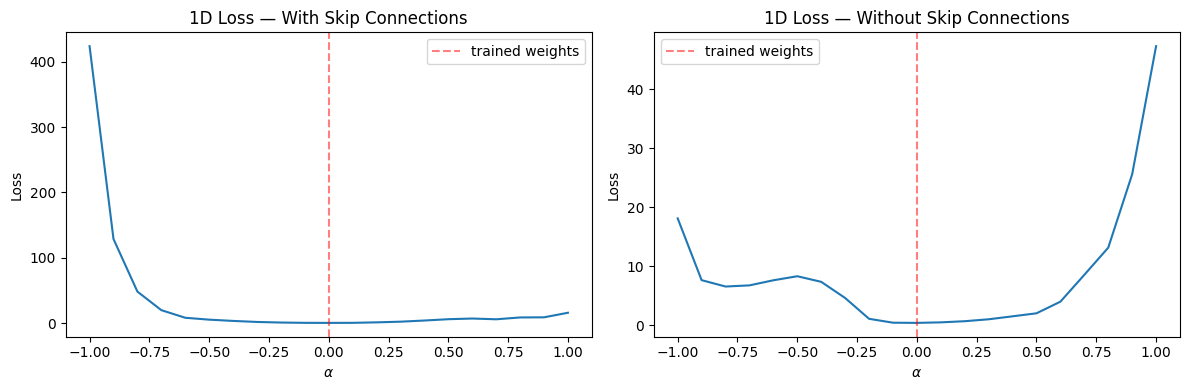

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(alphas, losses_1d_skip)
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel("Loss")
ax1.set_title("1D Loss — With Skip Connections")
ax1.legend()

ax2.plot(alphas, losses_1d_noskip)
ax2.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel("Loss")
ax2.set_title("1D Loss — Without Skip Connections")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Na zaprezentowanych wykresach można zauważyć, że dla modelu z skip-connections, krzywa jest gładka i asymetryczna - w prawo rośnie powoli i łagodnie, w lewo rośnie gwałtownie, ale monotonicznie. Jest to szeroka dolina. Model jest odporny na perturbacje wag w jednym kierunku.
# Dla modelu bez skip-connections, krzywa jest trochę bardziej chaotyczna i poszarpana - widać lokalne minima i garby po lewej stronie. To oznacza, że funkcja straty jest znacznie trudniejsza do optymalizacji.

In [17]:
def compute_loss_2d(
    model: nn.Module,
    direction1: list[torch.Tensor],
    direction2: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    betas: np.ndarray,
    device: torch.device = device,
) -> np.ndarray:
    """
    Compute loss on a 2D grid: f(alpha, beta) = L(theta* + alpha * d1 + beta * d2).

    Args:
        model: Trained model (parameters = theta*).
        direction1: First filter-normalized direction (delta).
        direction2: Second filter-normalized direction (eta).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values (x-axis).
        betas: Array of beta values (y-axis).
        device: Computation device.

    Returns:
        2D numpy array of shape (len(betas), len(alphas)) with loss values.
    """
    original_params = [p.data.clone() for p in model.parameters()]
    criterion = nn.CrossEntropyLoss()
    loss_grid = np.zeros((len(betas), len(alphas)))

    model.eval()
    with torch.no_grad():
        for i, beta in enumerate(tqdm(betas)):
            for j, alpha in enumerate(alphas):
                # Perturb: theta* + alpha * d1 + beta * d2
                for p, p0, d1, d2 in zip(model.parameters(), original_params, direction1, direction2):
                    p.data = p0 + alpha * d1.to(device) + beta * d2.to(device)

                # Evaluate loss over the full dataloader
                total_loss = 0.0
                total_samples = 0
                for images, labels in dataloader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    total_loss += loss.item() * images.size(0)
                    total_samples += images.size(0)

                loss_grid[i, j] = total_loss / total_samples

        # Restore original parameters
        for p, p0 in zip(model.parameters(), original_params):
            p.data = p0

    return loss_grid

In [18]:
GRID_SIZE = 11  # increase to 21 for smoother plots if you have a GPU
grid_points = np.linspace(-1, 1, GRID_SIZE)

dir1_skip = get_random_filter_normalized_direction(model_skip)
dir2_skip = get_random_filter_normalized_direction(model_skip)

dir1_noskip = get_random_filter_normalized_direction(model_noskip)
dir2_noskip = get_random_filter_normalized_direction(model_noskip)

print(f"Computing 2D landscape ({GRID_SIZE}x{GRID_SIZE} grid)...")

print("  Model WITH skip connections...")
grid_skip = compute_loss_2d(model_skip, dir1_skip, dir2_skip, eval_loader, grid_points, grid_points)

print("  Model WITHOUT skip connections...")
grid_noskip = compute_loss_2d(model_noskip, dir1_noskip, dir2_noskip, eval_loader, grid_points, grid_points)

Computing 2D landscape (11x11 grid)...
  Model WITH skip connections...


  0%|          | 0/11 [00:00<?, ?it/s]

  Model WITHOUT skip connections...


  0%|          | 0/11 [00:00<?, ?it/s]

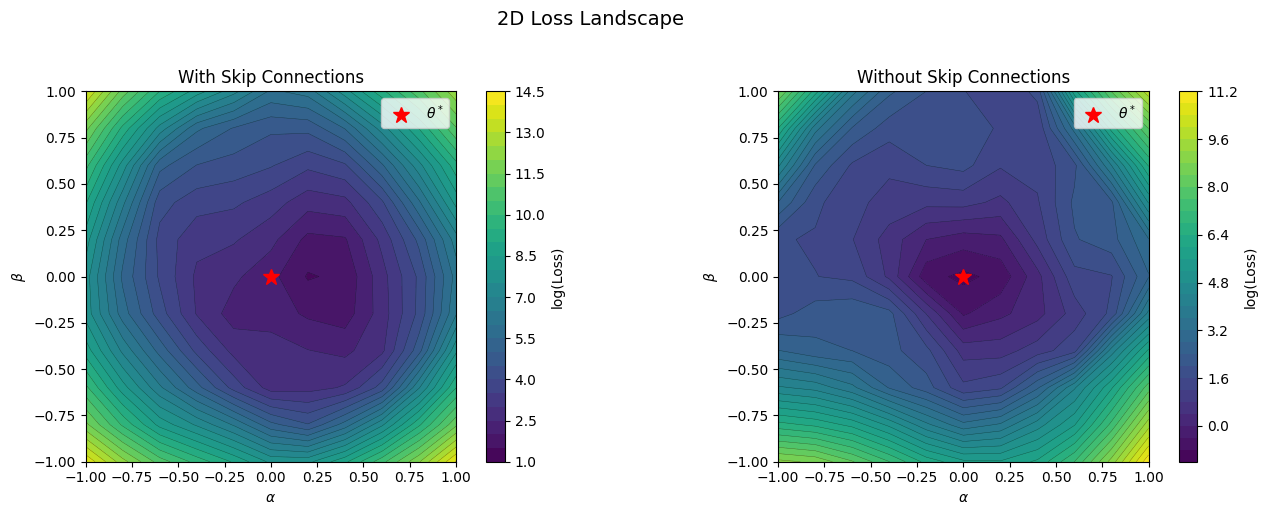

In [19]:
def plot_loss_contour(
    grid: np.ndarray, alphas: np.ndarray, betas: np.ndarray, title: str, ax=None, vmax: float | None = None,
) -> None:
    """Plot a 2D loss contour map."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    A, B = np.meshgrid(alphas, betas)
    plot_grid = np.log(grid) if grid.min() > 0 else grid
    if vmax is not None:
        plot_grid = np.clip(plot_grid, None, vmax)
    cf = ax.contourf(A, B, plot_grid, levels=30, cmap=cm.viridis)
    ax.contour(A, B, plot_grid, levels=30, colors="k", linewidths=0.3, alpha=0.5)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.plot(0, 0, "r*", markersize=12, label=r"$\theta^*$")
    ax.legend()
    plt.colorbar(cf, ax=ax, label="log(Loss)")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmax = max(np.log(grid_skip).max(), np.log(grid_noskip).max())
plot_loss_contour(grid_skip, grid_points, grid_points, "With Skip Connections", ax=ax1, vmax=vmax)
plot_loss_contour(grid_noskip, grid_points, grid_points, "Without Skip Connections", ax=ax2, vmax=vmax)

plt.suptitle("2D Loss Landscape", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Podobnie, jak w przypadku wizualizacji 1D, wykres konturowany dla with-skip-connection jest szeroki i regularny - kontury są równomiernie rozłożone i w miarę okrągłę. Od minimum strata rośnie powoli i symetrycznie.
# W przypadku without-skip-connections widać, że kontury są bardziej ściśnięte i nieregularne, szczególnie w rogach. Dolina jest węższa - strata rośnie szybsciej przy odejściu od minimum.

## Exercise 4: Comparison and Analysis

**Tasks:**

1. **Compare the 1D plots**: How do the curves differ between the model with skip connections and the one without? Which has a wider "valley" around the minimum?

2. **Compare the 2D contour plots**: Describe the shape differences. Are the contours more circular or elongated? Does the minimum appear sharper or flatter?

3. **Normalized vs. unnormalized directions**: Generate a direction **without** filter normalization (just `torch.randn_like(p)` for each parameter) and create the same 1D plot.

4. **Relate to training**: How do the landscape differences connect to the training curves you observed (loss convergence speed, final test accuracy)?

In [ ]:
# 1.
# Odpowiedziałem na te pytania już pod odpowiednimi wykresami, ale podsumowując:
# model z skip-connections charakteryzuje się gładkim, szerokim minimum funkcji straty, co oznacza
# że jest odporny na perturbacje wag i łatwiejszy do optymalizacji przez gradient descent.
# Model bez skip-connections ma bardziej chaotyczny krajobraz z lokalnymi minimami,
# co utrudnia optymalizację i tłumaczy niższą dokładność klasyfikacji.

# 2.
# Także odpowiedziałem na to pytanie pod odpowiednim wykresem, ale podsumowując:
# Model z skip-connections ma szerokie, regularne minimum z równomiernie rozłożonymi konturami,
# podczas gdy model bez skip-connections charakteryzuje się węższą, bardziej nieregularną doliną ze ściśniętymi konturami w rogach.

# 3.
# Kod do przeprowadzania tego testu umieściłem poniżej. Bez normalizacji parametrów, obie krzywe wyglądają praktycznie identycznie.
# Nie wynika z nich żadna infromacja, nie widać różnicy między modelem ze skipami a bez.
# Bez normalizacji, kierunek d ma losowe, niekontrolowane skale, dla małych alpha perturbacja jest znikoma i strata prawie się nie zmienia.
# Przy większych alpha jeden duży filtr dominuije i stara eksploduje gwałtownie.

# 4.

# Model z skip-connections zaczyna trening z niższą stratą (1.1 vs 1.35) i szybciej zbiega,
# konsekwentnie wyprzedzając model bez skipów przez cały trening, osiągając końcową dokładność 88.41%.
# Model bez skip-connections zbiega wolniej i osiąga wyższą stratę końcową, co przekłada się
# na niższą dokładność testową 85.64%.

# Model ze skipami wykazuje duże skoki dokładności w początkowych epokach (0-3) - skacze gwałtownie
# między 30% a 60%, co wynika z szerokiego i gładkiego krajobrazu funkcji straty, który pozwala
# optymalizatorowi na duże kroki gradientowe zanim ustabilizuje się w minimum.
# Model bez skipów jest stabilniejszy na początku treningu, gdyż jego wąski krajobraz
# wymusza ostrożniejsze, mniejsze kroki optymalizatora.

In [20]:
def get_random_direction(model: nn.Module) -> list[torch.Tensor]:
    """Generate a random direction in parameter space without filter-wise normalization."""
    return [torch.randn_like(p).detach() for p in model.parameters()]

In [21]:
alphas = np.linspace(-1, 1, 21)

dir_skip = get_random_direction(model_skip)
dir_noskip = get_random_direction(model_noskip)

print("Computing 1D landscape for model WITH skip connections without normalization...")
losses_1d_skip_no_norm = compute_loss_1d(model_skip, dir_skip, eval_loader, alphas)

print("Computing 1D landscape for model WITHOUT skip connections without normalization...")
losses_1d_noskip_no_norm = compute_loss_1d(model_noskip, dir_noskip, eval_loader, alphas)

Computing 1D landscape for model WITH skip connections without normalization...


  0%|          | 0/21 [00:00<?, ?it/s]

Computing 1D landscape for model WITHOUT skip connections without normalization...


  0%|          | 0/21 [00:00<?, ?it/s]

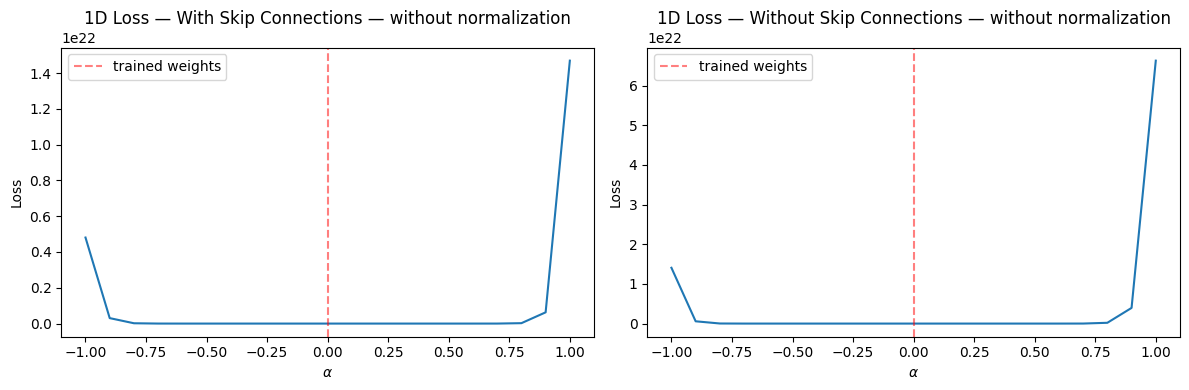

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(alphas, losses_1d_skip_no_norm)
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel("Loss")
ax1.set_title("1D Loss — With Skip Connections — without normalization")
ax1.legend()

ax2.plot(alphas, losses_1d_noskip_no_norm)
ax2.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel("Loss")
ax2.set_title("1D Loss — Without Skip Connections — without normalization")
ax2.legend()

plt.tight_layout()
plt.show()

## Discussion Questions

1. The paper claims that skip connections "prevent the explosion of non-convexity" as depth increases. Based on your experiments, do you agree? What mechanism might explain this?

2. Why is filter normalization essential for comparing loss landscapes across different architectures? What would go wrong without it?

3. The paper found that large-batch training produces sharper minima and worse generalization. How could you test this using the tools you've built in this lab?

In [ ]:
# 1.
# Tak, wyniki to potwierdzają. Wykres 1D dla modelu ze skipami jest gładki i monotoniczny, podczas gdy bez skipów widać lokalne minima i garby — czyli właśnie niekonweksyjność.
# Wykres 1D dla modelu ze skipami wygląda na gładszy, a bez skipów ma więcej „garbów”. Skip connections pomagają, bo ułatwiają przepływ gradientu i stabilizują uczenie, przez co krajobraz straty jest "łagodniejszy" i mniej poszarpany w praktyce.

# 2.
# Wykresy bez normalizacji pokazują to wprost - obie krzywe wyglądają identycznie i są nieinformatywne. Bez normalizacji norma kierunku d rośnie wraz z rozmiarem filtra, więc większe filtry dominują perturbację.
# Przy małych alpha nic się nie dzieje, przy dużych strata eksploduje. Nie można wtedy porównywać modeli bo wykres pokazuje tylko "jak duże są filtry", a nie geometrię krajobrazu.

# 3.
# Używając dokładnie tych samych narzędzi - wytrenować dwie wersje modelu: jedną z małym batchem (np. 32), drugą z dużym (np. 512), a następnie użyć compute_loss_1d i compute_loss_2d na obu.
# Zgodnie z hipotezą papieru model trenowany z dużym batchem powinien mieć węższe, ostrzejsze minimum na wykresach konturowych, a krzywa 1D powinna rosnąć szybciej po obu stronach alpha=0.